In [1]:
import pandas as pd,numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.tsa.seasonal import seasonal_decompose,STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

# 构建XGBoost模型
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import datetime

plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_excel('../data/1121.xlsx')
data.columns = ['date','consumption']
data['date']=pd.to_datetime(data['date'])
data = data.set_index('date').asfreq('MS')
data['consumption'] = data['consumption'].astype(float)

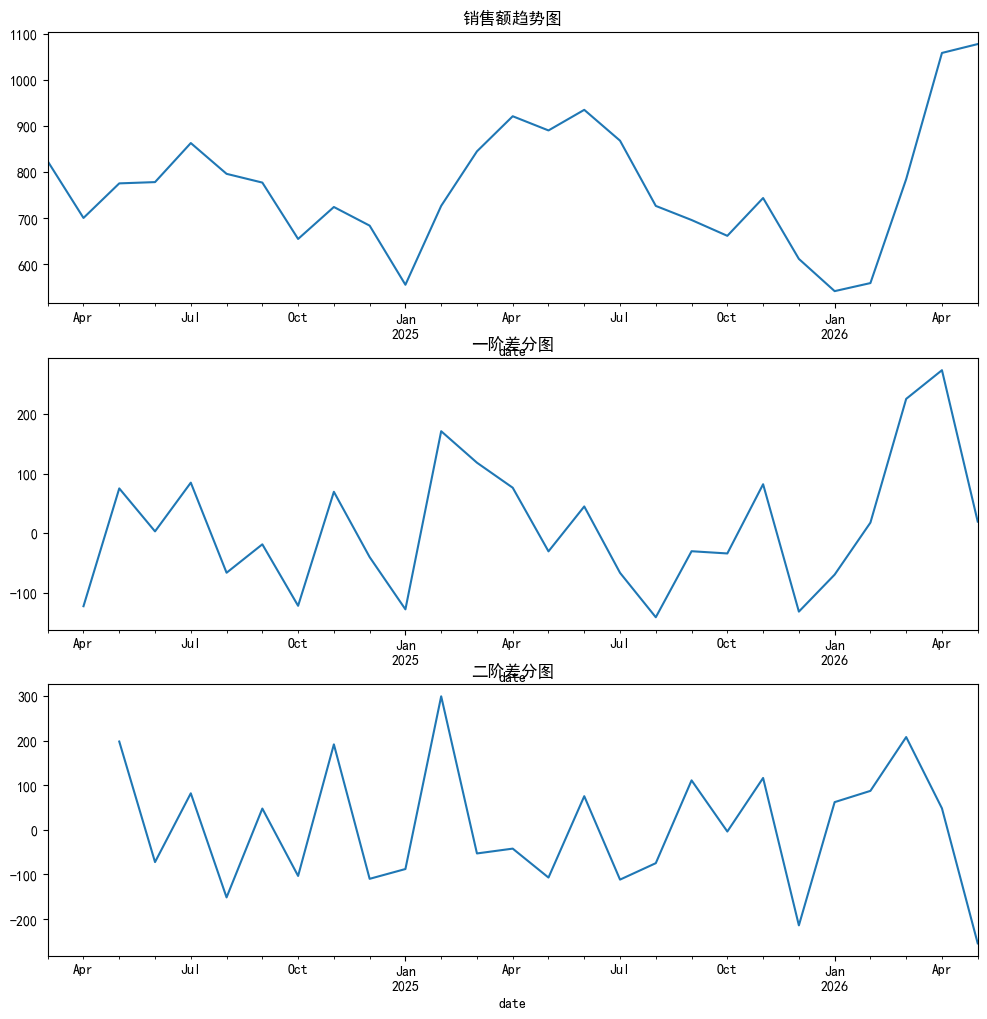

In [4]:
fig,axs = plt.subplots(3,1,figsize=(12,12))
data['consumption'].plot(title='销售额趋势图',ax = axs[0])
data['consumption'].diff().plot(title='一阶差分图',ax=axs[1])
data['consumption'].diff().diff().plot(title='二阶差分图',ax=axs[2])
plt.savefig('../image/salestrend.png')

### 未差分前的数据已围绕某值波动；差分后的数据更明显，符合平稳特性

In [5]:
print(f"  变异系数: {data['consumption'].std()/data['consumption'].mean()*100:>13.2f}%")

  变异系数:         17.77%


### 变异系数17.77% 数据相对稳定，波动幅度相对较小
##### 数据“纯净度”/同质性：CV < 15% 通常说明数据非常稳定、聚集；CV > 30% 说明数据极其离散，存在大量异常值或剧烈波动。

In [6]:
data['mon_pct'] = data['consumption'].pct_change() * 100 # 环比
data['yoy_pct'] = data['consumption'].pct_change(12) *100 # 同比

In [7]:
# 年度汇总
yearly_stats = data.groupby(data.index.year)['consumption'].agg(['mean','sum','std','min','max'])
yearly_stats['cv'] = yearly_stats['std']/yearly_stats['mean'] * 100
yearly_stats

,mean,sum,std,min,max,cv
date,,,,,,
2024,757.753000,7577.53,65.301824,655.02,862.94,8.617825
2025,765.175833,9182.11,125.055533,555.73,934.97,16.343372
2026,804.382000,4021.91,259.037813,541.91,1077.54,32.203333


### 变异系数逐年上升，反映波动加剧，后续可使用乘法季节性

In [8]:
# 季节特征
monthly_avg = data.groupby(data.index.month)['consumption'].mean()
overall_avg = data['consumption'].mean()
monthly_index = (monthly_avg/overall_avg *100).round(2)

In [9]:
print("\n月份季节性指数 (100=平均水平):")
month_names = ['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月']
for m, idx_val in monthly_index.items():
    bar = '█' * int(idx_val / 5)
    print(f"  {month_names[m-1]:>4s}: {idx_val:>6.1f} {bar}")
print(f" 基准月:"," 100.0","█"*20)


月份季节性指数 (100=平均水平):
    1月:   71.3 ██████████████
    2月:   83.5 ████████████████
    3月:  106.2 █████████████████████
    4月:  116.1 ███████████████████████
    5月:  118.8 ███████████████████████
    6月:  111.3 ██████████████████████
    7月:  112.5 ██████████████████████
    8月:   98.9 ███████████████████
    9月:   95.7 ███████████████████
   10月:   85.5 █████████████████
   11月:   95.4 ███████████████████
   12月:   84.2 ████████████████
 基准月:  100.0 ████████████████████


### 消耗数据呈现明显的季节特征，3-5月份为消耗高峰期，1月为季度低谷（春节假期效应）；季节振幅47.5个指数点，季节因素对消耗波动有显著影响

In [10]:
#STL时间序列分解
stl = STL(data['consumption'],period=12,robust=True)
stl_result = stl.fit()
trend = stl_result.trend
seasonal = stl_result.seasonal
residual = stl_result.resid

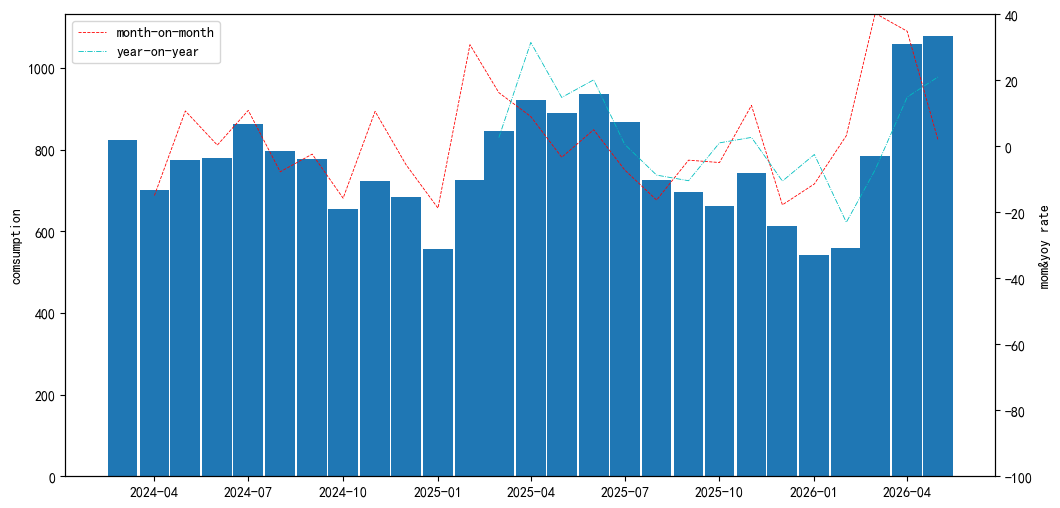

In [11]:
x_vals = (seasonal.index - pd.Timestamp('1970-01-01')).days  # 得到整数天数
# 计算相邻点的平均天数间隔，并设定柱子宽度为间隔的 95%（消除空白）
if len(x_vals) > 1:
    avg_spacing = np.mean(np.diff(x_vals))   # 例如 30.4 天
    width = avg_spacing * 0.95               # 留极小间隙，若想要完全紧贴，可设为 avg_spacing
else:
    width = 30  # 若仅一个点，设置默认宽度 30 天
fig,axs = plt.subplots(figsize=(12,6))
axs.bar(x_vals,data['consumption'],width=width,label = 'consumption',align='center')
axs.set(ylabel='comsumption')
axs1 = axs.twinx()
axs1.plot(data['mon_pct'],'r--',label='month-on-month',linewidth=0.6)
axs1.plot(data['yoy_pct'],'c-.',label='year-on-year',linewidth=0.6)
axs1.set(ylim=(-100,40),ylabel='mom&yoy rate')
axs1.legend()
plt.savefig('../image/comsumption_mom_yoy.jpg')
plt.show()

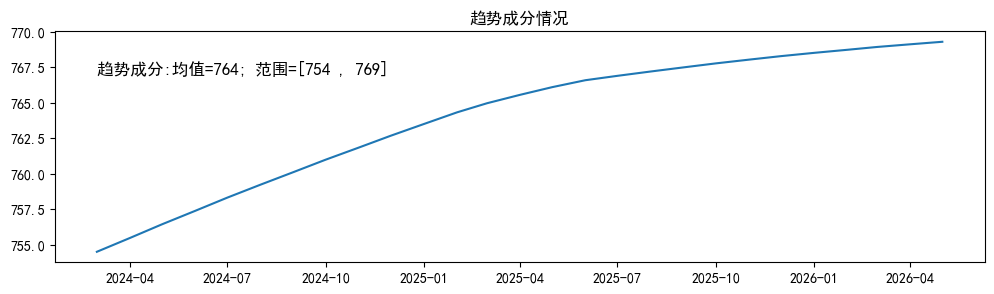

In [12]:
trend_text = f"趋势成分:均值={trend.mean():,.0f}; 范围=[{trend.min():,.0f} , {trend.max():,.0f}]"
plt.figure(figsize=(12,3))
plt.plot(trend)
plt.title('趋势成分情况')
# plt.xticks(rotation=60)
plt.text(trend.index[0],trend.max()*0.997,trend_text,fontsize=12)
plt.savefig('../image/trend.png')
plt.show()

### 长期趋势明显，数据在长周期内呈现的持续上升.

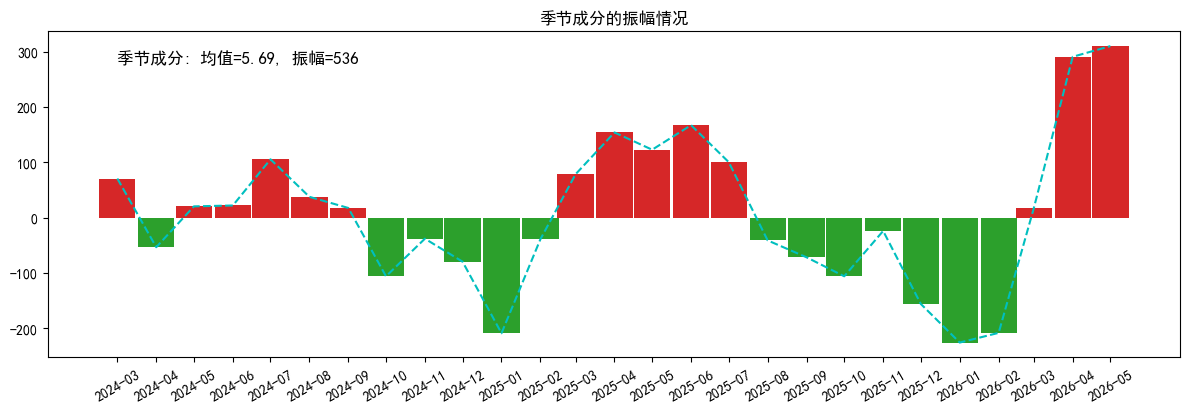

In [13]:
seasonal_text = f"季节成分: 均值={seasonal.mean():,.2f}, 振幅={seasonal.max()-seasonal.min():,.0f}"
colors = ["tab:red" if x>0 else "tab:green" for x in seasonal.values]    
plt.figure(figsize=(12,4))
plt.bar(x_vals,seasonal.values,width=width,color=colors)
plt.plot(seasonal,'c--')
plt.title('季节成分的振幅情况')
plt.tight_layout()
plt.xticks(x_vals, seasonal.index.strftime('%Y-%m'), rotation=30)
plt.text(x_vals[0],seasonal.max()*0.9,seasonal_text,fontsize=12)
plt.savefig('../image/seasonal_amplitude.png')
plt.show()

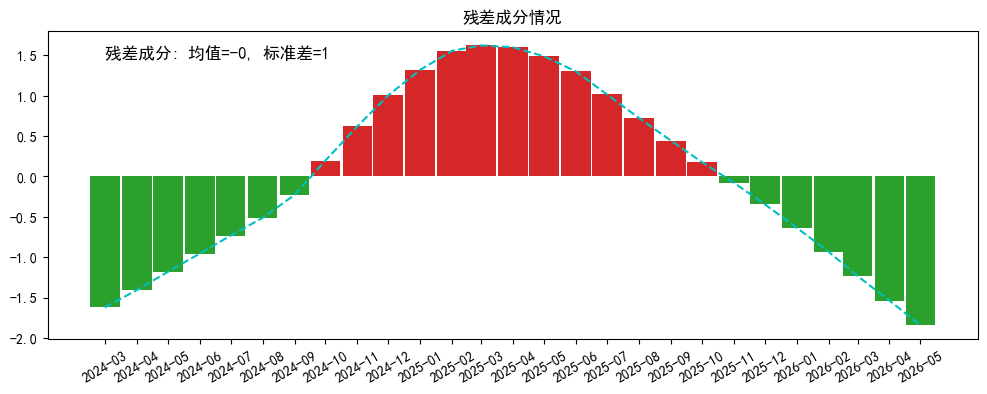

In [14]:
residual_text = f"残差成分: 均值={residual.mean():,.0f}, 标准差={residual.std():,.0f}"
residual_color = ["tab:red" if x>0 else "tab:green" for x in residual.values]
plt.figure(figsize=(12,4))
plt.bar(x_vals,residual.values,width=width,color=residual_color,align='center')
plt.plot(residual,'c--')
plt.title('残差成分情况')
plt.xticks(x_vals, residual.index.strftime('%Y-%m'), rotation=30)
plt.text(x_vals[0],residual.max()*0.9,residual_text,fontsize=12)
plt.savefig('../image/residual.png')
plt.show()

### 残差表明数据带有强烈的、非线性的长期上涨趋势

In [15]:
#分解质量：残差占比
ss_total=((data['consumption'] - data['consumption'].mean())**2).sum()
ss_residual = (residual**2).sum()
r_squred = 1-ss_residual/ss_total
print(f"分解拟合度: {r_squred}")

分解拟合度: 0.999932285935625


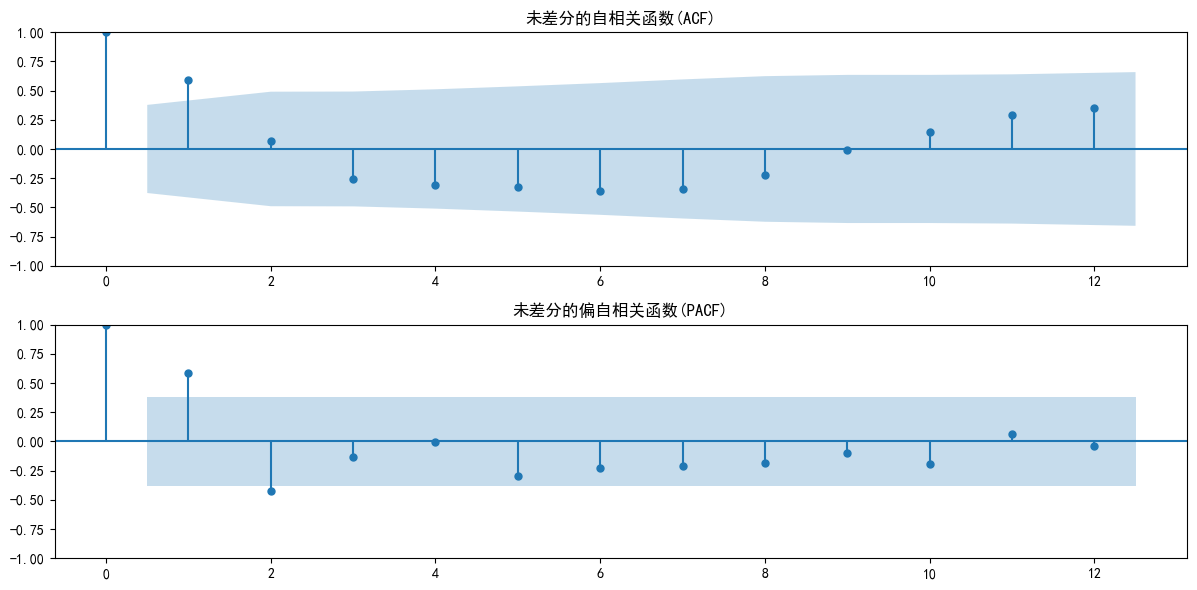

In [16]:
data_diff = data['consumption']
fig,axs = plt.subplots(2,1,figsize=(12,6))
plot_acf(data_diff,lags=12,alpha=0.05,ax=axs[0])
axs[0].set_title('未差分的自相关函数(ACF)')
plot_pacf(data_diff,lags=12,alpha=0.05,ax=axs[1])
axs[1].set_title('未差分的偏自相关函数(PACF)')
plt.tight_layout()
plt.savefig('../image/acf_pacf.png')
plt.show()

### 未差分前acp在2阶截尾，pacf在3阶截尾，基本确定p=2,q=3
### 数据没有长期上涨或下跌的惯性（均值回归很快，快速接近0），序列围绕一个恒定均值波动

#### 数据存在“前高后低”或“脉冲回落”的固定模式。比如，滞后1期（上个月）数值很高（ACF=0.58），但接下来连续几个月（滞后2-8期）数值都被“拉低”到均值以下（ACF为负值）；这表明数据中存在负的移动平均（负MA）效应

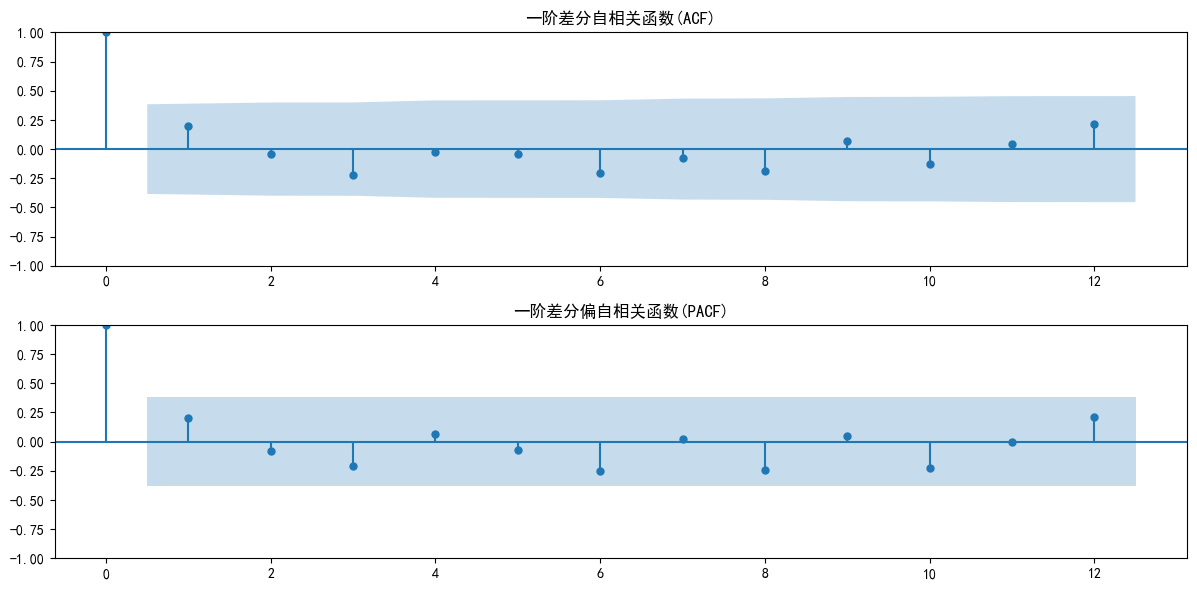

In [17]:
data_diff_1 = data['consumption'].diff().dropna()
fig,axs = plt.subplots(2,1,figsize=(12,6))
plot_acf(data_diff_1,lags=12,alpha=0.05,ax=axs[0])
axs[0].set_title('一阶差分自相关函数(ACF)')
plot_pacf(data_diff_1,lags=12,alpha=0.05,ax=axs[1])
axs[1].set_title('一阶差分偏自相关函数(PACF)')
plt.tight_layout()
plt.savefig('../image/acf_pacf_1.png')


plt.show()

### 差分后：ACF在滞后3期（-0.24）、6期（-0.25）、7期（-0.25）、8期（-0.25） 全部显著为负，且持续稳定在 -0.25 附近；普通差分（Lag=1）完全无法消除年度周期性，需要的不是普通差分，而是季节差分（Lag=12）

In [18]:
# 平稳性
def adf_test(series,name):
    result = adfuller(series.dropna(),autolag='AIC')
    labels=['统计量','p值','使用滞后阶数','观测数']
    critical = result[4]
    print(f"\n [------{name}-------]")
    for i,label in enumerate(labels):
        print(f"    {label}: {result[i]:.4f}")
    print('临界值: ')
    for key,val in critical.items():
        print(f"    {key}:{val:.4f}")
    if result[1]<=0.05:
        print(f"    结论: p={result[1]:.4f} ≤0.05 → 序列平稳   ✔")
    else:
        print(f"    结论: p={result[1]:.4f} >0.05 → 序列非平稳 ×")
    return result[1]

In [19]:
p_original = adf_test(data['consumption'],'原始序列')
p_diff1 = adf_test(data['consumption'].diff().dropna(),'一阶差分序列')
p_diff1_s12 = adf_test(data['consumption'].diff().diff(12).dropna(),'一阶差分+季节差分')


 [------原始序列-------]
    统计量: -4.4326
    p值: 0.0003
    使用滞后阶数: 9.0000
    观测数: 17.0000
临界值: 
    1%:-3.8893
    5%:-3.0544
    10%:-2.6670
    结论: p=0.0003 ≤0.05 → 序列平稳   ✔

 [------一阶差分序列-------]
    统计量: -4.5698
    p值: 0.0001
    使用滞后阶数: 9.0000
    观测数: 16.0000
临界值: 
    1%:-3.9240
    5%:-3.0685
    10%:-2.6739
    结论: p=0.0001 ≤0.05 → 序列平稳   ✔

 [------一阶差分+季节差分-------]
    统计量: -4.1937
    p值: 0.0007
    使用滞后阶数: 0.0000
    观测数: 13.0000
临界值: 
    1%:-4.0689
    5%:-3.1271
    10%:-2.7017
    结论: p=0.0007 ≤0.05 → 序列平稳   ✔


### ADF 检验显示原始序列平稳（p=0.0003），ACF 快速衰减，支持平稳性。

In [20]:
#ACF/PACF
diff_series = data['consumption'].diff().dropna()
n_diff = len(diff_series)
max_lags = min(12,int(n_diff * 0.5) - 1)
acf_values = acf(diff_series,nlags=max_lags,fft=True)
pacf_values = pacf(diff_series,nlags=max_lags)

print(f"一阶差分后 ACF (前 {max_lags} 阶): ")
for i in range(1,max_lags+1):
    sig = "***" if abs(acf_values[i]) > 1.96/np.sqrt(len(diff_series)) else ""
    print(f"    Lag {i:2d}: {acf_values[i]:>8.4f} {sig}")

print(f"一阶差分后 PACF (前 {max_lags} 阶): ")
for i in range(1,max_lags + 1):
    sig = "***" if abs(pacf_values[i]) > 1.96/np.sqrt(len(diff_series)) else ""
    print(f"    Lag {i:2d}: {pacf_values[i]:>8.4f} {sig}")
conf_interval = 1.96 / np.sqrt(len(diff_series))
print(f"\n  显著性边界(95%): ±{conf_interval:.4f}")

一阶差分后 ACF (前 12 阶): 
    Lag  1:   0.1991 
    Lag  2:  -0.0413 
    Lag  3:  -0.2215 
    Lag  4:  -0.0249 
    Lag  5:  -0.0414 
    Lag  6:  -0.2009 
    Lag  7:  -0.0794 
    Lag  8:  -0.1896 
    Lag  9:   0.0692 
    Lag 10:  -0.1316 
    Lag 11:   0.0451 
    Lag 12:   0.2161 
一阶差分后 PACF (前 12 阶): 
    Lag  1:   0.2070 
    Lag  2:  -0.0915 
    Lag  3:  -0.2332 
    Lag  4:   0.0762 
    Lag  5:  -0.0903 
    Lag  6:  -0.3291 
    Lag  7:   0.0241 
    Lag  8:  -0.3759 
    Lag  9:   0.0849 
    Lag 10:  -0.4578 ***
    Lag 11:   0.0338 
    Lag 12:   0.4662 ***

  显著性边界(95%): ±0.3844


In [21]:
# 模型构建与评估
# 划分训练集与测试集：最后三个月做测试（保留24个月训练满足HW的2个季节周期要求）
train_size = len(data) - 3
train = data['consumption'][:train_size]
test = data['consumption'][train_size:]
print(f"训练集: {train.index[0].strftime('%Y-%m')} - {train.index[-1].strftime('%Y-%m')} ( {len(train)} 个月); ")
print(f"测试集: {test.index[0].strftime('%Y-%m')} - {test.index[-1].strftime('%Y-%m')} ( {len(test)} 个月); ")

训练集: 2024-03 - 2026-02 ( 24 个月); 
测试集: 2026-03 - 2026-05 ( 3 个月); 


In [22]:
#SARIMA 模型 网格搜索最优模型
best_aic = np.inf
best_order = None
best_seasonal_order = None
best_sarima = None
#根据ACF/PACF和ADF结果设定搜索范围
for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0,4):
            for P in range(0,2):
                for D in range(0,2):
                    for Q in range(0,2):
                        try:
                            model = SARIMAX(train,order=(p,d,q),seasonal_order=(P,D,Q,12),enforce_invertibility=False,enforce_stationarity=False)
                            result = model.fit(disp=False,maxiter=200)
                            if result.aic < best_aic:
                                best_aic = result.aic
                                best_order = (p,d,q)
                                best_seasonal_order = (P,D,Q,12)
                                best_sarima = result
                        except:
                            continue

In [23]:
print(f"最优参数: SARIMAX {best_order} × {best_seasonal_order}")
print(f"  AIC: {best_sarima.aic}")
print(f"  BIC: {best_sarima.bic}")

最优参数: SARIMAX (0, 0, 0) × (0, 1, 1, 12)
  AIC: 4.0
  BIC: nan


In [24]:
#Ljung-Box检验（残差白噪声）
lb_test = acorr_ljungbox(best_sarima.resid,lags=10,return_df=True)
lb_p = lb_test['lb_pvalue'].iloc[-1]
print(f"Ljungbox检验 p值(lag=10): {lb_p:.4f} → {'残差白噪声' if lb_p > 0.05 else '残差存在自相关'}")

Ljungbox检验 p值(lag=10): 0.0000 → 残差存在自相关


#### 搜索范围 p(0-3), d(0-1), q(0-3), P(0-1), D(0-1), Q(0-1) 基本合理。
#### 结果异常：最优为 SARIMAX(0,0,0) × (0,1,1,12)，非季节部分全为 0，AIC 仅为 4.0（极低），且 BIC 为 NaN。
#### 因为数据量小（24 个月），模型过于简单，导致 AIC 异常低，但 Ljung-Box 检验 p=0.0000 明确表明残差存在强自相关，模型欠拟合，不可接受
#### 改进方法：增大搜索范围（如 p,q 到 3 或 4），使用 auto_arima（如 pmdarima）自动选择。

In [25]:
import pmdarima as pm

# 自动搜索最优SARIMA模型
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    # 非季节性参数范围 (p, d, q)
    start_p=0, max_p=4,       # 根据ACF/PACF分析，AR阶数可能不高
    start_q=0, max_q=4,       # 搜索MA阶数0-3
    d=0,                   # 让auto_arima自动检测最优差分阶数
    # 季节性参数范围 (P, D, Q)
    start_P=0, max_P=3,
    start_Q=0, max_Q=3,
    D=1,                   # 让auto_arima自动检测季节差分阶数，强制季节差分
    # 其他控制
    stepwise=True,            # 开启，否则搜索会非常慢
    trace=True,               # 开启，观察搜索过程
)
print('-'*100)
# 查看最优模型的摘要
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=149.580, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=150.932, Time=0.10 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=147.731, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=151.580, Time=0.02 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=151.576, Time=0.07 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=148.932, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=149.936, Time=0.05 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=inf, Time=0.08 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12]          
Total fit time: 0.629 seconds
----------------------------------------------------------------------------------------------------
                                SARIMAX Results                                 
Dep. Variable:                        y   No. Obs

In [26]:
auto_pre,conf_int = auto_model.predict(n_periods=3,return_conf_int=True,alpha=0.05)
print(auto_pre)
print(conf_int)

2026-03-01    844.95
2026-04-01    921.08
2026-05-01    890.31
Freq: MS, dtype: float64
[[ 639.33415236 1050.56584764]
 [ 715.46415236 1126.69584764]
 [ 684.69415236 1095.92584764]]


In [27]:
# SARIMA 测试集预测
sarima_pred = best_sarima.get_forecast(steps=3)
sarima_mean = sarima_pred.predicted_mean
sarima_ci = sarima_pred.conf_int(alpha=0.2) #置信度区间80%

In [28]:
df = pd.concat([test,sarima_mean,sarima_ci],axis=1)
df

,consumption,predicted_mean,lower consumption,upper consumption
2026-03-01,784.76,844.95,716.575568,973.324432
2026-04-01,1058.32,921.08,792.705568,1049.454432
2026-05-01,1077.54,890.31,761.935568,1018.684432


In [29]:
# Holt-Winters三指数平滑
hw_result = {}
for trend_type in ['add','mul']:
    for seasonal_type in ['add','mul']:
        for init_method in ['estimated','legacy-heuristic','heuristic']:
            try:
                hw_model = ExponentialSmoothing(train,trend=trend_type,seasonal=seasonal_type,seasonal_periods=12,initialization_method=init_method)
                hw_fit = hw_model.fit(optimized=True)
                hw_result[(trend_type,seasonal_type)] = hw_fit
                print(f"HW({trend_type},{seasonal_type}): AIC={hw_fit.aic:.2f}, SSE={hw_fit.sse:.2f} [init={init_method}]")
                # break
            except Exception as e:
                if init_method == 'heuristic':
                    print(f"HW({trend_type},{seasonal_type}): 失败-{str(e)[:60]}")

HW(add,add): AIC=217.46, SSE=54467.76 [init=estimated]
HW(add,add): AIC=235.89, SSE=117404.46 [init=legacy-heuristic]
HW(add,add): AIC=235.18, SSE=113991.18 [init=heuristic]
HW(add,mul): AIC=217.02, SSE=53488.73 [init=estimated]
HW(add,mul): AIC=236.92, SSE=122567.59 [init=legacy-heuristic]
HW(add,mul): AIC=233.60, SSE=106723.65 [init=heuristic]
HW(mul,add): AIC=217.50, SSE=54568.14 [init=estimated]
HW(mul,add): AIC=235.93, SSE=117590.00 [init=legacy-heuristic]
HW(mul,add): AIC=235.25, SSE=114317.61 [init=heuristic]
HW(mul,mul): AIC=216.98, SSE=53394.95 [init=estimated]
HW(mul,mul): AIC=236.97, SSE=122808.15 [init=legacy-heuristic]
HW(mul,mul): AIC=233.66, SSE=106984.69 [init=heuristic]


In [30]:
#选择最优模型，如果全失败则使用简单指数平滑
if hw_result:
    best_hw_key = min(hw_result,key=lambda k:hw_result[k].aic)
    best_hw = hw_result[best_hw_key]
    print(f"最优HW: trend={best_hw_key[0]}, seasonal = {best_hw_key[1]}, AIC={best_hw.aic:.2f}")
else:
    print('所有HW模型均已失败，使用简单趋势指数平滑')
    best_hw_key = ('add',None)
    best_hw = ExponentialSmoothing(train,trend='add',seasonal=None,initialization_method='estimated').fit(optimized=True)
    print(f"简单趋势HW: AIC={best_hw.aic:.2f}")

最优HW: trend=add, seasonal = mul, AIC=233.60


In [31]:
#hw测试集预测
hw_forecast = best_hw.forecast(3)
df = pd.concat([df,hw_forecast],axis=1).rename(columns={0:'hw_predicted'})
df

,consumption,predicted_mean,lower consumption,upper consumption,hw_predicted
2026-03-01,784.76,844.95,716.575568,973.324432,759.301813
2026-04-01,1058.32,921.08,792.705568,1049.454432,821.727206
2026-05-01,1077.54,890.31,761.935568,1018.684432,805.803737


In [32]:
#ARIMA基准模型
arima_model = ARIMA(train,order=(1,1,1))
arima_result = arima_model.fit()
print(f"ARIMA(1,1,1): AIC={arima_result.aic:.2f}")
arima_forecast = arima_result.forecast(3)
df = pd.concat([df,arima_forecast],axis=1)
df

ARIMA(1,1,1): AIC=276.08


,consumption,predicted_mean,lower consumption,upper consumption,hw_predicted,predicted_mean
2026-03-01,784.76,844.95,716.575568,973.324432,759.301813,597.760434
2026-04-01,1058.32,921.08,792.705568,1049.454432,821.727206,627.574430
2026-05-01,1077.54,890.31,761.935568,1018.684432,805.803737,650.733999


In [33]:
#朴素季节性基准(上一年同期)
naive_forecast = []
for i in range(3):
    idx = train_size + i
    if idx>=12:
        naive_forecast.append(data['consumption'].iloc[idx-12])
    else:
        naive_forecast.append(train.mean())
naive_forecast = pd.Series(naive_forecast,index=test.index)
df = pd.concat([df,naive_forecast],axis=1)
df

,consumption,predicted_mean,lower consumption,upper consumption,hw_predicted,predicted_mean,0
2026-03-01,784.76,844.95,716.575568,973.324432,759.301813,597.760434,844.95
2026-04-01,1058.32,921.08,792.705568,1049.454432,821.727206,627.574430,921.08
2026-05-01,1077.54,890.31,761.935568,1018.684432,805.803737,650.733999,890.31


In [34]:
#构建特征
original_train = data['consumption'].copy().reset_index()
def timeSeriesFeature(original,forecast=None):
    if forecast:
        original = pd.concat([original,forecast],axis=0)
    for i in range(1,4):
        original[f"lag_{i}"] = original['consumption'].shift(i)
    original['month'] = original['date'].dt.month
    original['rolling_mean_3'] = original['consumption'].rolling(window=3).mean()
    original['rolling_3_cv'] = original['consumption'].rolling(window=3).std()/original['consumption'].rolling(window=3).mean()
    original['rolling_mean_6'] = original['consumption'].rolling(window=6).mean()
    original['rolling_6_cv'] = original['consumption'].rolling(window=6).std()/original['consumption'].rolling(window=6).mean()
    original['diff'] = original['consumption'] - original['lag_1']
    original['mon_pct'] = original['consumption'].pct_change().shift(1)*100
    original = original.dropna()
    return original
df_train = timeSeriesFeature(original_train)
df_train.tail()

,date,consumption,lag_1,lag_2,lag_3,month,rolling_mean_3,rolling_3_cv,rolling_mean_6,rolling_6_cv,diff,mon_pct
22,2026-01-01,541.91,611.78,743.79,661.81,1,632.493333,0.162091,663.678333,0.114676,-69.87,-17.748289
23,2026-02-01,559.38,541.91,611.78,743.79,2,571.023333,0.063677,635.796667,0.124259,17.47,-11.420772
24,2026-03-01,784.76,559.38,541.91,611.78,3,628.683333,0.215448,650.571667,0.151311,225.38,3.223783
25,2026-04-01,1058.32,784.76,559.38,541.91,4,800.820000,0.312002,716.656667,0.270845,273.56,40.291037
26,2026-05-01,1077.54,1058.32,784.76,559.38,5,973.540000,0.168222,772.281667,0.316814,19.22,34.859065


In [35]:
feature_cols = ['mon_pct','lag_1', 'lag_2', 'lag_3','month','rolling_mean_3','rolling_mean_6','diff','rolling_3_cv','rolling_6_cv']
X = df_train[feature_cols]
y = df_train['consumption']

# 4. 划分训练集和测试集 (注意：时间序列必须按时间顺序划分，不能打乱)
train_size = int(len(X))-3
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
# 初始化XGBoost回归器
xgb_model = xgb.XGBRegressor()

# 训练模型
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
y_pred = xgb_model.predict(X_test)

# 评估模型
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'XGBoost 测试集RMSE: {rmse}')

XGBoost 测试集RMSE: 157.48233523910767


In [37]:
xgb_forecast = pd.Series(y_pred,index=test.index)
xgb_forecast

date
2026-03-01    691.348511
2026-04-01    862.627258
2026-05-01    912.068848
Freq: MS, dtype: float32

In [38]:
#模型评估与对比
def calc_metrics(actual,predicted):
    mae = np.mean(np.abs(actual-predicted))
    rmse = np.sqrt(np.mean((actual-predicted)**2))
    mape = np.mean(np.abs((actual-predicted)/actual))*100
    # MASE(相对于朴素预测)
    naive_errors = np.abs(np.diff(train))
    mase = mae/np.mean(naive_errors)
    return {'MAE':mae,'RMSE':rmse,'MAPE':mape,'MASE':mase}
models_pred = {
    'SARIMA': sarima_mean,
    'Holt-Winters': hw_forecast,
    'ARIMA(1,1,1)': arima_forecast,
    '朴素季节基准': naive_forecast,
    'Auto-Sarima':auto_pre,
    'XGBoost:':xgb_forecast,
}

In [39]:
print(f"\n{'模型':<16s} {'MAE':>10s} {'RMSE':>10s} {'MAPE(%)':>8s} {'MASE':>8s}")
print("-" * 56)
metrics_all = {}
for name, pred in models_pred.items():
    m = calc_metrics(test.values, pred.values)
    metrics_all[name] = m
    print(f"{name:<16s} {m['MAE']:>10,.0f} {m['RMSE']:>10,.0f} {m['MAPE']:>8.2f} {m['MASE']:>8.3f}")


模型                      MAE       RMSE  MAPE(%)     MASE
--------------------------------------------------------
SARIMA                  128        138    12.67    1.689
Holt-Winters            178        209    16.94    2.343
ARIMA(1,1,1)            348        366    34.71    4.586
朴素季节基准                  128        138    12.67    1.689
Auto-Sarima             128        138    12.67    1.689
XGBoost:                152        157    15.25    1.996


In [40]:
# 选择 Auto-Sarima\XGBoost\H-w 使用误差倒数确定模型权重
# 权重与模型在验证集上的平均绝对误差（MAE）成反比，即误差越大的模型权重越小
mae_sarima = np.mean(np.abs(auto_pre.values - test.values))
mae_hw = np.mean(np.abs(hw_forecast.values - test.values))
mae_xgb = np.mean(np.abs(xgb_forecast.values - test.values))

inv_mae = [1/mae_sarima, 1/mae_hw, 1/mae_xgb]
weights = np.array(inv_mae) / np.sum(inv_mae)
print("误差倒数权重:", weights)

误差倒数权重: [0.38958704 0.28074585 0.32966711]


In [41]:
# 全量训练
full_data = data['consumption']
finaly_sarima = SARIMAX(full_data,order=auto_model.order,seasonal_order=auto_model.seasonal_order,enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=300)
sarima_future = finaly_sarima.get_forecast(steps=6)
sarima_future_mean = sarima_future.predicted_mean
sarima_future_ci80 = sarima_future.conf_int(alpha=0.2)
sarima_future_ci95 = sarima_future.conf_int(alpha=0.05)
sarima_future_mean

2026-06-01    934.97
2026-07-01    868.14
2026-08-01    726.67
2026-09-01    696.11
2026-10-01    661.81
2026-11-01    743.79
Freq: MS, Name: predicted_mean, dtype: float64

In [42]:
if best_hw_key[1] is not None:
    final_hw = ExponentialSmoothing(
        full_data, trend=best_hw_key[0], seasonal=best_hw_key[1],
        seasonal_periods=12, initialization_method='estimated'
    ).fit(optimized=True)
else:
    final_hw = ExponentialSmoothing(
        full_data, trend=best_hw_key[0], seasonal=None,
        initialization_method='estimated'
    ).fit(optimized=True)
hw_future = final_hw.forecast(6)
hw_future

2026-06-01    954.763505
2026-07-01    960.924602
2026-08-01    843.328617
2026-09-01    815.141370
2026-10-01    729.725975
2026-11-01    813.323486
Freq: MS, dtype: float64

In [43]:
#构建多步预测XGB模型
xgb_final_data = data['consumption'].reset_index()
xgb_data = timeSeriesFeature(xgb_final_data)
xgb_train_x = xgb_data[feature_cols]
xgb_train_y = xgb_data['consumption']
final_xgb_model = xgb.XGBRegressor()
final_xgb_model.fit(xgb_train_x,xgb_train_y)
def xgb_multiple_predict(setps,startTime,original):
    future_steps = setps
    dt = pd.to_datetime(str(startTime))
    original_train = original.copy()
    # 用最新的已知数据作为初始输入
    last_known = original[feature_cols].iloc[-1].values.reshape(1, -1) 
    predictions = []
    dtl = []
    # dtl.append(startTime)
    for i in range(future_steps):
        next_pred = final_xgb_model.predict(last_known)[0]
        predictions.append(next_pred)
        # 更新输入特征：将新预测值加入，并丢弃最旧的值
        dtll = datetime.datetime(dt.year,dt.month+i,1).strftime("%Y-%m-%d")
        dtl.append(dtll)
        forecast_data = pd.DataFrame([[pd.to_datetime(dtll),next_pred]],columns=["date","consumption"])
        original_train = pd.concat([original_train,forecast_data],axis=0)
        last_known = timeSeriesFeature(original_train)
        last_known = last_known[feature_cols].iloc[-1].values.reshape(1,-1)
    return pd.Series(predictions,index=dtl)
xgb_future = xgb_multiple_predict(6,'2026-6-1',xgb_final_data)
xgb_future

2026-06-01    1077.538696
2026-07-01     944.633118
2026-08-01     902.402039
2026-09-01     743.078064
2026-10-01     716.900879
2026-11-01     882.067566
dtype: float32

In [44]:
# 集成预测 
ensemble_future = sarima_future_mean * weights[0] + hw_future * weights[1] + xgb_future.values * weights[2]
ensemble_future

2026-06-01    987.527153
2026-07-01    919.406178
2026-08-01    817.354503
2026-09-01    745.011391
2026-10-01    699.038792
2026-11-01    808.896805
Freq: MS, dtype: float64

In [45]:
# x_future = pd.Series(xgb_future.values())
future_dates = pd.date_range(start='2026-06-01', periods=6, freq='MS')
month_labels_future = [d.strftime('%Y-%m') for d in future_dates]
print(f"\n{'月份':<10s} {'SARIMA':>10s} {'Holt-Winters':>16s} {'XGB':>6s} {'集成预测':>12s} {'SARIMA下限(80%)':>10s} {'SARIMA上限(80%)':>12s}")
for i, d in enumerate(future_dates):
    s_val = sarima_future_mean.iloc[i]
    h_val = hw_future.iloc[i]
    x_val = xgb_future.values[i]
    e_val = ensemble_future.iloc[i]
    lo = sarima_future_ci80.iloc[i, 0]
    hi = sarima_future_ci80.iloc[i, 1]
    print(f"{d.strftime('%Y-%m'):<10s} {s_val:>12,.0f} {h_val:>14,.0f} {x_val:>12,.0f} {e_val:>12,.0f} {lo:>12,.0f} {hi:>12,.0f}")


月份             SARIMA     Holt-Winters    XGB         集成预测 SARIMA下限(80%) SARIMA上限(80%)
2026-06             935            955        1,078          988          786        1,084
2026-07             868            961          945          919          719        1,017
2026-08             727            843          902          817          578          876
2026-09             696            815          743          745          547          845
2026-10             662            730          717          699          513          811
2026-11             744            813          882          809          595          893
